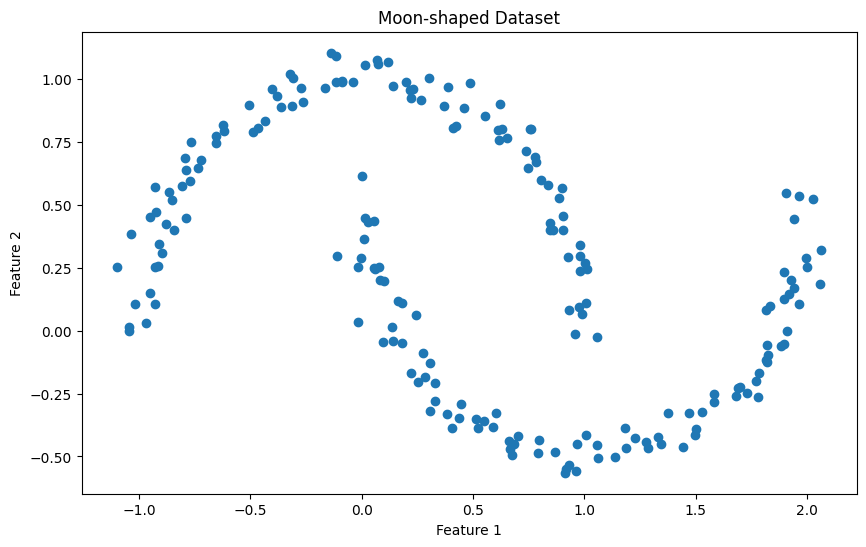

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

X, _ = make_moons(n_samples=200, noise=0.05, random_state=42)

# Visualize the dataset
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1])
plt.title('Moon-shaped Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

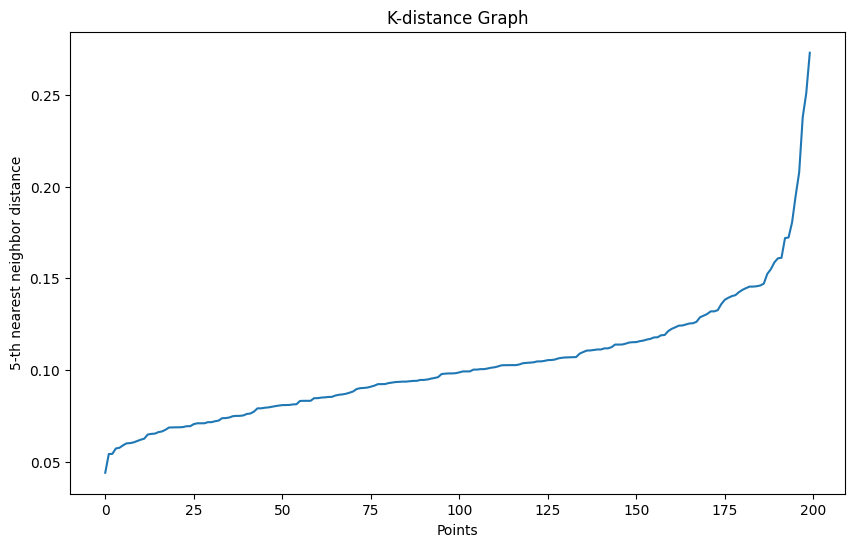

In [2]:
# Function to plot k-distance graph
def plot_k_distance_graph(X, k):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X)
    distances, _ = neigh.kneighbors(X)
    distances = np.sort(distances[:, k-1])
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.show()
# Plot k-distance graph
plot_k_distance_graph(X, k=5)

In [ ]:
# Perform DBSCAN clustering
epsilon = 0.15  # Chosen based on k-distance graph
min_samples = 5  # 2 * num_features (2D data)
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
clusters = dbscan.fit_predict(X)

# Visualize the results
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis')
plt.colorbar(scatter)
plt.title('DBSCAN Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Print number of clusters and noise points
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)
print(f'Number of clusters: {n_clusters}')
print(f'Number of noise points: {n_noise}')

[10:41 am, 09/03/2026] +91 99553 30373: Scenario: Customer Segmentation for a Retail Store
Context:
A retail store wants to understand its customers better. They have data on how much each customer spends per visit and how frequently they visit the store. The goal is to group customers into clusters (e.g., “loyal high spenders,” “occasional visitors,” etc.) using DBSCAN, which is great for finding clusters of varying shapes and identifying outliers.
[10:41 am, 09/03/2026] +91 99553 30373: data = np.array([
    [5000, 50], [5200, 48], [4800, 52],   # Loyal high spenders
    [1500, 10], [1600, 12], [1400, 9],    # Occasional visitors
    [3000, 25], [3100, 27], [2900, 24],   # Moderate spenders
    [8000, 5],                            # Outlier: rare but huge spender
    [200, 2],                             # Outlier: very low engagement
])

Cluster labels: [ 0  0  0  1  1  1  2  2  2 -1 -1]


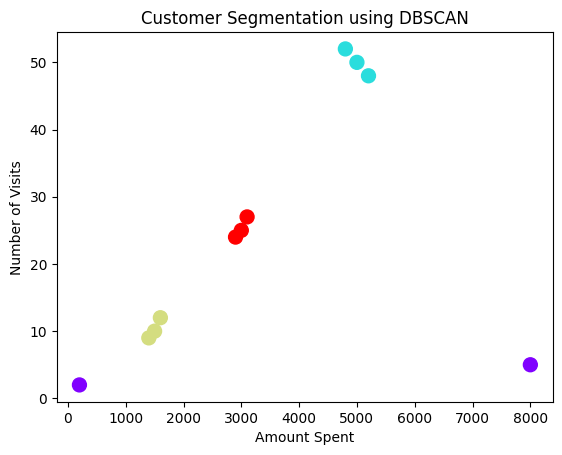

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

data = np.array([
    [5000, 50], [5200, 48], [4800, 52],   # Loyal high spenders
    [1500, 10], [1600, 12], [1400, 9],    # Occasional visitors
    [3000, 25], [3100, 27], [2900, 24],   # Moderate spenders
    [8000, 5],                            # Outlier
    [200, 2]                              # Outlier
])

# Step 1: Standard Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

dbscan = DBSCAN(eps=0.6, min_samples=2)
labels = dbscan.fit_predict(scaled_data)

print("Cluster labels:", labels)

# Step 3: Visualization
plt.scatter(data[:,0], data[:,1], c=labels, cmap='rainbow', s=100)
plt.xlabel("Amount Spent")
plt.ylabel("Number of Visits")
plt.title("Customer Segmentation using DBSCAN")
plt.show()

Scenario: Fine‑tune ResNet‑50 for Music Genre Classification
Context:
A streaming service wants to automatically classify songs into genres (e.g., rock, jazz, classical, hip‑hop, electronic). They have 4,000 audio tracks labeled by genre. Instead of training from scratch, they’ll fine‑tune a ResNet‑50 pretrained on ImageNet, but adapted to work with spectrogram images of audio.

📊 Dataset
- Convert each audio track into a Mel‑spectrogram (visual representation of sound frequencies over time).
- Each spectrogram is treated like an image (RGB channels).
- Dataset: 4,000 spectrograms across 5 genres.

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

audio_dataset_path = "audio_dataset"
spectrogram_path = "spectrogram_dataset"

genres = ['rock','jazz','classical','hiphop','electronic']

for genre in genres:

    os.makedirs(os.path.join(spectrogram_path, genre), exist_ok=True)

    folder = os.path.join(audio_dataset_path, genre)

    for file in os.listdir(folder):

        file_path = os.path.join(folder, file)

        y, sr = librosa.load(file_path, duration=30)

        mel = librosa.feature.melspectrogram(y=y, sr=sr)

        mel_db = librosa.power_to_db(mel, ref=np.max)

        plt.figure(figsize=(3,3))
        librosa.display.specshow(mel_db, sr=sr)

        save_path = os.path.join(spectrogram_path, genre, file.replace(".wav",".png"))

        plt.axis("off")
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
        plt.close()

print("Spectrogram images created")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

dataset_path = "sample_pneumonia_xray_dataset/pneumonia_dataset"

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    root=f"{dataset_path}/train",
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=f"{dataset_path}/val",
    transform=val_transforms
)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 2)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

epochs = 5

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

print("Validation Accuracy:", 100 * correct / total)

